## IDS Modeling

Network Duplicate, we need no trainings here

In [1]:
# Load modules and define the surface-potential PINN
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from phis_init import phi_init
from Channel_Current_Ich import channel_integral_I_phi


class DeltaPhisPINN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.Tanh(),
            nn.Linear(8, 1),
        )


    def forward(
        self,
        Vgs,
        Vds,
    ):

        Vgs = Vgs.reshape(-1, 1)
        Vds = Vds.reshape(-1, 1)

        x = torch.cat(
            [
                Vgs,
                Vds,
            ],
            dim=1,
        )

        return self.net(x)


device = "cpu"


dtype = torch.float32

## Parameters transfer
Need to be correspondent

In [2]:
# Physical and voltage parameters
T = 300.0
NA = 1.0e16

eps_sic = (
    9.26
    * 8.854e-14
)

Cox = 7.0e-8

Vfbs0 = -1.0

Dit_mid = 2.0e11
Dit_edge = 2.0e13
sigma_it = 0.1

Eg = 3.26
Ec_minus_Ei = Eg / 2.0

Qox = 1.602e-7


# Valid domain of phis_PINN.pth
VGS_MIN = -10.0
VGS_MAX = 30.0

VDS_MIN = 0.0
VDS_MAX = 15.0

We must use the same PINN as PINN_phis.ipynb(of surface potential Φs) to get Φs0, ΦsL(Φs is their substraint)

In [3]:
# Load trained surface-potential PINN
Model = DeltaPhisPINN().to(
    device=device,
    dtype=dtype,
)

state_dict = torch.load(
    "phis_PINN.pth",
    map_location=device,
    weights_only=True,
)

Model.load_state_dict(
    state_dict,
    strict=True,
)

Model.eval()

print(
    "Surface-potential PINN loaded."
)

Surface-potential PINN loaded.


Redefine Outputs

In [4]:
# Predict surface potential
@torch.no_grad()
def predict_phis(
    model,
    Vgs,
    phi_f,
):

    Vgs = torch.as_tensor(
        Vgs,
        dtype=dtype,
        device=device,
    ).reshape(-1, 1)

    phi_f = torch.as_tensor(
        phi_f,
        dtype=dtype,
        device=device,
    ).reshape(-1, 1)


    phis_init_value = phi_init(
        Vgs,
        phi_f,
        T,
        NA,
        eps_sic,
        Cox,
        Vfbs0,
        Dit_mid,
        Dit_edge,
        sigma_it,
        Eg,
    ).reshape(-1, 1)


    delta_phis = model(
        Vgs,
        phi_f,
    )


    phis = (
        phis_init_value
        + delta_phis
    )


    return phis

## Params Definition


In [5]:
# I-V model parameters and Eqs. (17)-(21)

# Initial parameters; these must later be extracted/fitted to measured I-V data.
K_CURRENT = 1.0e5

LCH_CM = 5.0e-5

LAMBDA_CLM = 0.01

VSAT = 2.0e7

VDS_SAT = 10.0

DELTA_SAT = 2.0


# Eq. (19) mobility components
MU_B = 900.0
MU_SP = 300.0
MU_C = 500.0
MU_SR = 150.0
MU_DR = 1000.0


# Eq. (19)
def calculate_mu_LF(
    ref,
):

    mu_B = ref.new_tensor(MU_B)
    mu_SP = ref.new_tensor(MU_SP)
    mu_C = ref.new_tensor(MU_C)
    mu_SR = ref.new_tensor(MU_SR)
    mu_DR = ref.new_tensor(MU_DR)


    inv_mu_LF = (
        1.0 / mu_B
        + 1.0 / mu_SP
        + 1.0 / mu_C
        + 1.0 / mu_SR
        + 1.0 / mu_DR
    )


    mu_LF = (
        1.0
        / inv_mu_LF
    )


    return (
        torch.ones_like(ref)
        * mu_LF
    )


# Eq. (21)
def calculate_Vds_eff(
    Vds,
):

    Vds = torch.clamp(
        Vds,
        min=0.0,
    )


    Vdssat = Vds.new_tensor(
        VDS_SAT
    )


    Delta = Vds.new_tensor(
        DELTA_SAT
    )


    Vds_eff = (

        Vds

        * (
            1.0

            + (
                Vds
                / Vdssat
            ) ** Delta

        ) ** (
            -1.0
            / Delta
        )
    )


    return Vds_eff


# Eq. (20)
def calculate_mu_eff(
    mu_LF,
    phis_s0,
    phis_sL,
):

    Lch = phis_s0.new_tensor(
        LCH_CM
    )

    vsat = phis_s0.new_tensor(
        VSAT
    )


    Ey = (

        torch.abs(
            phis_sL
            - phis_s0
        )

        / Lch
    )


    a = (
        Ey
        / vsat
    ) ** 2


    a_safe = torch.clamp(
        a,
        min=1.0e-20,
    )


    mu_eff_squared = (

        torch.sqrt(
            1.0
            + 4.0
            * a_safe
            * mu_LF**2
        )

        - 1.0

    ) / (
        2.0
        * a_safe
    )


    mu_eff_squared = torch.where(

        a < 1.0e-12,

        mu_LF**2,

        mu_eff_squared,

    )


    mu_eff = torch.sqrt(
        torch.clamp(
            mu_eff_squared,
            min=0.0,
        )
    )


    return mu_eff


# Complete forward I-V model
@torch.no_grad()
def predict_Ids(
    model,
    Vgs,
    Vds,
):

    Vgs = torch.as_tensor(
        Vgs,
        dtype=dtype,
        device=device,
    ).reshape(-1, 1)


    Vds = torch.as_tensor(
        Vds,
        dtype=dtype,
        device=device,
    ).reshape(-1, 1)


    # Eq. (21)
    Vds_eff = calculate_Vds_eff(
        Vds
    )


    # Source-side surface potential: phi_f = 0
    phi_f_source = torch.zeros_like(
        Vds_eff
    )


    phis_s0 = predict_phis(
        model,
        Vgs,
        phi_f_source,
    )


    # Drain-side surface potential: phi_f = Vds_eff
    phis_sL = predict_phis(
        model,
        Vgs,
        Vds_eff,
    )


    # Eq. (18)
    I_phi = channel_integral_I_phi(

        Vgs,

        Vds_eff,

        phis_s0,

        phis_sL,

        Vfbs0,

        Cox,

        Qox,

        Dit_mid,

        Dit_edge,

        sigma_it,

        Ec_minus_Ei,

        T,

        NA,

        Eg,

        eps_sic,

    )


    # Eq. (19)
    mu_LF = calculate_mu_LF(
        Vgs
    )


    # Eq. (20)
    mu_eff = calculate_mu_eff(

        mu_LF,

        phis_s0,

        phis_sL,

    )


    K = Vgs.new_tensor(
        K_CURRENT
    )


    lam = Vgs.new_tensor(
        LAMBDA_CLM
    )


    # Eq. (17)
    Ids = (

        K

        * mu_eff

        * (
            1.0
            + lam
            * Vds_eff
        )

        * I_phi
    )


    Ids = torch.clamp(
        Ids,
        min=0.0,
    )


    return Ids

Final Transfer

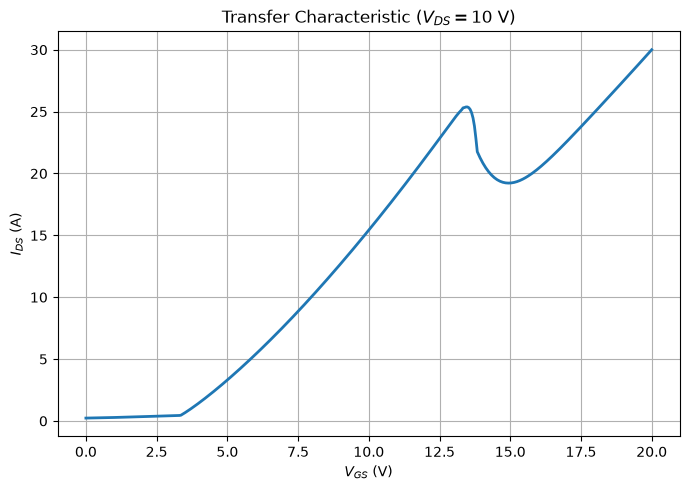

In [6]:
# Fig. 5(b)-style transfer characteristic
N_VGS = 400

VDS_TRANSFER = 10.0


Vgs_transfer = torch.linspace(
    0.0,
    20.0,
    N_VGS,
    dtype=dtype,
    device=device,
).reshape(-1, 1)


Vds_transfer = torch.full_like(
    Vgs_transfer,
    VDS_TRANSFER,
)


Ids_transfer = predict_Ids(
    Model,
    Vgs_transfer,
    Vds_transfer,
)


plt.figure(
    figsize=(7, 5)
)


plt.plot(
    Vgs_transfer.cpu().numpy(),
    Ids_transfer.cpu().numpy(),
    linewidth=2,
)


plt.xlabel(
    r"$V_{GS}$ (V)"
)


plt.ylabel(
    r"$I_{DS}$ (A)"
)


plt.title(
    r"Transfer Characteristic ($V_{DS}=10$ V)"
)


plt.grid(
    True
)


plt.tight_layout()


plt.show()

Output Curve

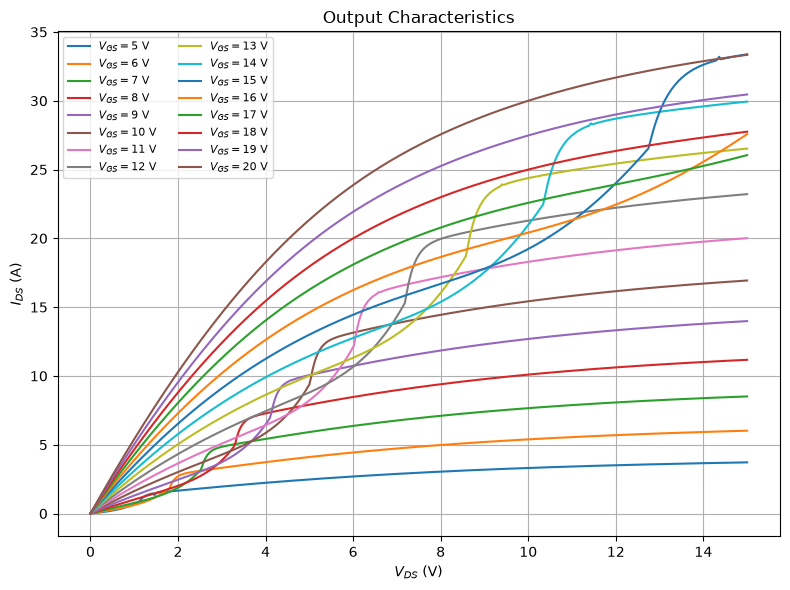

In [7]:
# Fig. 5(a)-style output characteristics
N_VDS = 400


Vds_output = torch.linspace(
    0.0,
    VDS_MAX,
    N_VDS,
    dtype=dtype,
    device=device,
).reshape(-1, 1)


VGS_OUTPUT = [
    5.0,
    6.0,
    7.0,
    8.0,
    9.0,
    10.0,
    11.0,
    12.0,
    13.0,
    14.0,
    15.0,
    16.0,
    17.0,
    18.0,
    19.0,
    20.0,
]


plt.figure(
    figsize=(8, 6)
)


with torch.no_grad():

    for VGS_VALUE in VGS_OUTPUT:


        Vgs_output = torch.full_like(
            Vds_output,
            VGS_VALUE,
        )


        Ids_output = predict_Ids(

            Model,

            Vgs_output,

            Vds_output,

        )


        plt.plot(

            Vds_output.cpu().numpy(),

            Ids_output.cpu().numpy(),

            linewidth=1.5,

            label=rf"$V_{{GS}}={VGS_VALUE:.0f}$ V",

        )


plt.xlabel(
    r"$V_{DS}$ (V)"
)


plt.ylabel(
    r"$I_{DS}$ (A)"
)


plt.title(
    r"Output Characteristics"
)


plt.grid(
    True
)


plt.legend(
    ncol=2,
    fontsize=8,
)


plt.tight_layout()


plt.show()

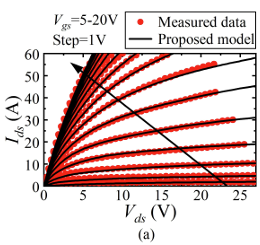